In [1]:
import torch
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
import os
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import numpy as np
import torch.nn as nn
import torch.optim as optim
import json
from tqdm.notebook import tqdm
import gc
import cv2
import matplotlib.pyplot as plt
import timm

In [2]:
transformation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = ImageFolder(root='../data/classification_data/train_data', transform=transformation)
train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True,    
    num_workers=4,   
    pin_memory=True   
)

num_classes = len(train_dataset.classes)

In [3]:
class MobileViT(nn.Module):
    def __init__(self, num_classes=1):
        super(MobileViT, self).__init__()
        
        self.base_model = timm.create_model('mobilevit_xs.cvnets_in1k', pretrained=True)
    
        self.avgpool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(1)
        )
    

        self.classifier = nn.Sequential(
            nn.Linear(384, num_classes)
        )

    def features(self, x):
            return self.base_model.forward_features(x)

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

load the model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MobileViT(num_classes=num_classes)
checkpoint_path = '../models/best_supervised_model_ViT.pth'

state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

Using device: cuda


MobileViT(
  (base_model): ByobNet(
    (stem): ConvNormAct(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
    )
    (stages): Sequential(
      (0): Sequential(
        (0): BottleneckBlock(
          (conv1_1x1): ConvNormAct(
            (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
          )
          (conv2_kxk): ConvNormAct(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (bn): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

image tensor function

In [5]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def load_and_crop_face(image_path):
    """
    Detects a face in the image, crops it with a small padding margin,
    and returns it as a normalized PyTorch tensor.
    """
    # Read image with OpenCV
    img_cv = cv2.imread(image_path)
    if img_cv is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")
        
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    if len(faces) == 0:
        print(f"⚠️ Warning: No face detected in {image_path}. Using full image instead.")
        # Fallback to the full image if detection fails
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
    else:
        # Take the largest detected face (x, y, width, height)
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
        
        # Add a 10% padding margin so we don't slice off ears or hair completely
        shrink_w = int(w * 0.05)
        shrink_h = int(h * 0.05)
        
        y1 = y + shrink_h
        y2 = y + h - shrink_h
        x1 = x + shrink_w
        x2 = x + w - shrink_w
        
        # Crop the face
        face_crop = img_cv[y1:y2, x1:x2]
        
        # Convert BGR (OpenCV) to RGB (PIL/PyTorch expected)
        gray_face = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
        img_rgb = cv2.merge([gray_face, gray_face, gray_face])
        pil_img = Image.fromarray(img_rgb)

        plt.figure(figsize=(3, 3))
        plt.imshow(img_rgb)
        plt.title(f"Cropped Face:\n{image_path.split('/')[-1]}")
        plt.axis('off')
        plt.show()
        
    # Apply your exact PyTorch transformations
    return transformation(pil_img)

In [6]:
def get_face_embedding(model, image_tensor, device):
    """
    Takes an image tensor and returns its 1280-dimensional normalized vector.
    """
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        if image_tensor.dim() == 3:
            image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension if single image

        # Pass through the feature extractor backbone
        features = model.features(image_tensor)
        
        # Global Average Pooling to get a flat vector
        embeddings = model.avgpool(features).flatten(1)
        
        # Normalize the vector to unit length (L2 Normalization)
        # This makes Cosine Similarity identical to a simple dot product
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
    return embeddings.cpu().squeeze()

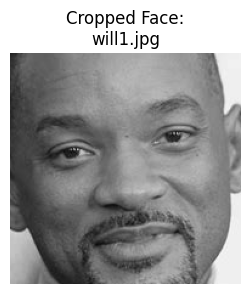

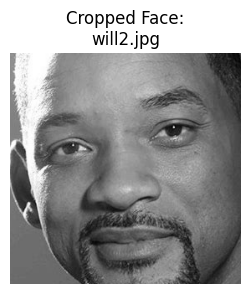

Cosine Similarity Score: 0.8587
Verification Result: MATCH DETECTED


In [9]:
# Path to test face images
image_path_1 = "../test_images/will1.jpg"
image_path_2 = "../test_images/will2.jpg"

# Get the image tensors
tensor_1 = load_and_crop_face(image_path_1)
tensor_2 = load_and_crop_face(image_path_2)

# Extract the embedding vectors
embedding_1 = get_face_embedding(model, tensor_1, device)
embedding_2 = get_face_embedding(model, tensor_2, device)

# Compare them using Cosine Similarity
# Cosine similarity requires a batch dimension, so we use unsqueeze(0)
similarity = F.cosine_similarity(embedding_1.unsqueeze(0), embedding_2.unsqueeze(0)).item()

print(f"Cosine Similarity Score: {similarity:.4f}")

threshold = 0.70  
if similarity >= threshold:
    print("Verification Result: MATCH DETECTED")
else:
    print("Verification Result: DIFFERENT PEOPLE")